# ============================================================
# 🏏 IPL DATA ANALYSIS — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# Dataset  : Indian Premier League (IPL) Match Data
# Tool     : Python (Pandas, Matplotlib, Seaborn)
# Goal     : Uncover patterns in team performance, venues,
#            players, and match outcomes
# Author   : Usman Haider
# Date     : 2024
# ============================================================

# Loading the Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df = pd.read_csv("IPL.csv")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

# Basic Information

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [3]:
df.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [4]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

null_percent = (df.isnull().sum() / len(df) * 100).round(2)
print(null_percent[null_percent > 0])

Duplicate Rows: 0
Series([], dtype: float64)


Check the size of rows and columns of the dataset

In [5]:
print("Dataset Shape:", df.shape)
print(f"Your rows are {df.shape[0]} and your columns are {df.shape[1]}")

Dataset Shape: (74, 20)
Your rows are 74 and your columns are 20


In [6]:
print(df.columns)

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='str')


In [7]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000


Now let's see how many columns have null values in total.

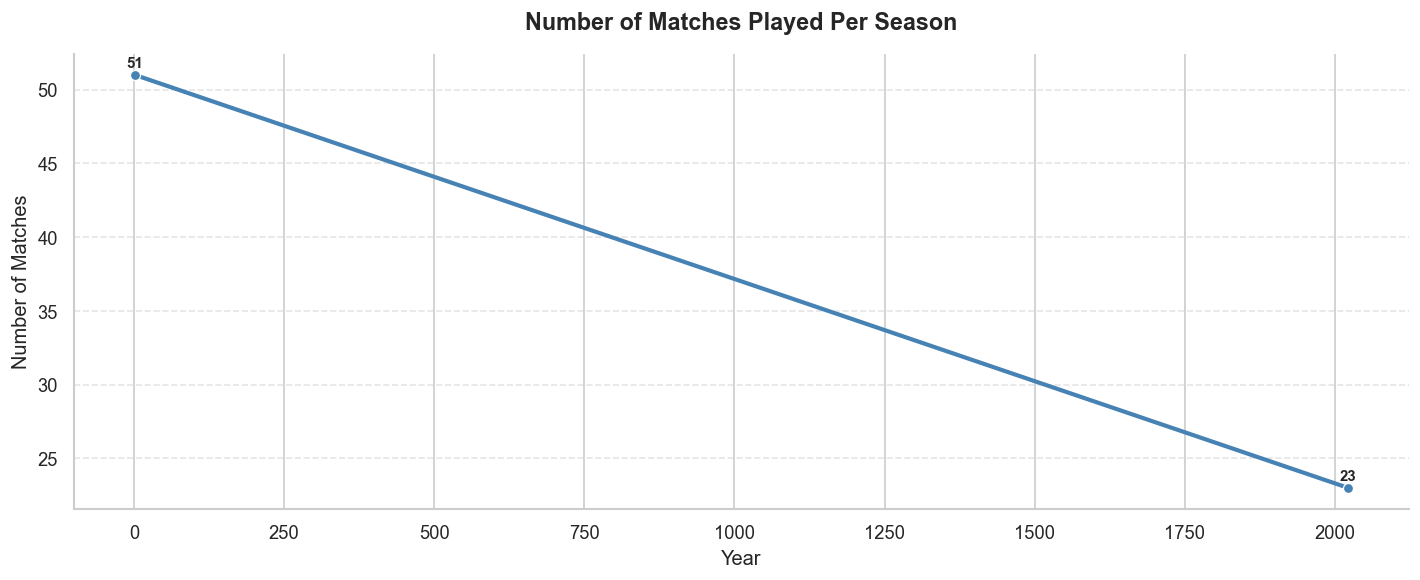

📊 Insight: IPL has grown consistently over the years, reflecting increasing popularity and expansion of teams.


In [8]:
df['year'] = pd.to_datetime(df['date']).dt.year

season_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    x=season_counts.index,
    y=season_counts.values,
    marker='o',
    color='steelblue',
    linewidth=2.5,
    ax=ax
)

for x, y in zip(season_counts.index, season_counts.values):
    ax.text(x, y + 0.5, str(y), ha='center', fontsize=9, fontweight='bold')

ax.set_title("Number of Matches Played Per Season",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Matches", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

print("📊 Insight: IPL has grown consistently over the years, "
      "reflecting increasing popularity and expansion of teams.")

# Now, Here comes some Basic Questions

1.Which team won the most matches?

In [9]:
match_win = df['match_winner'].value_counts()
match_win

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

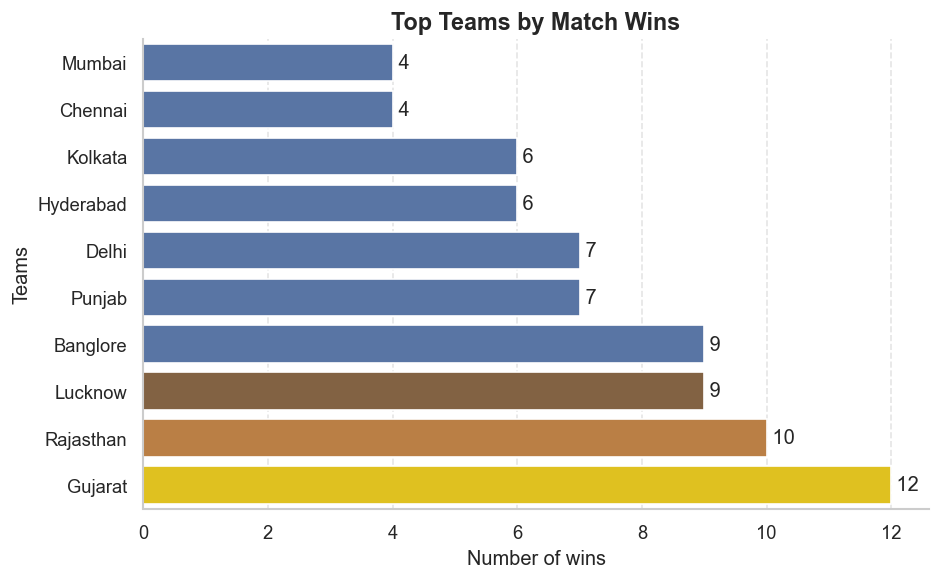

In [10]:
plt.figure(figsize=(8,5))

match_win_sorted = match_win.sort_values(ascending=True)
colors =[]
for i in range(len(match_win_sorted)):
    if i == len(match_win_sorted) -1:
        colors.append("#FFD700")
    elif i == len(match_win_sorted)-2:
        colors.append("#CD7F32")
    elif i == len(match_win_sorted)-3:
        colors.append("#8C6239")
    else:
        colors.append("#4C72B0")

ax=sns.barplot(x = match_win_sorted.values ,
            y = match_win_sorted.index,
            palette =colors)

for i, v in enumerate(match_win_sorted.values):
    ax.text(v, i, f" {v}", va='center')
    
plt.title("Top Teams by Match Wins", fontsize=14, fontweight="bold")
plt.xlabel("Number of wins")
plt.ylabel("Teams")
plt.grid(axis="x", linestyle="--", alpha=0.5)
sns.despine()           
plt.tight_layout()
plt.show()

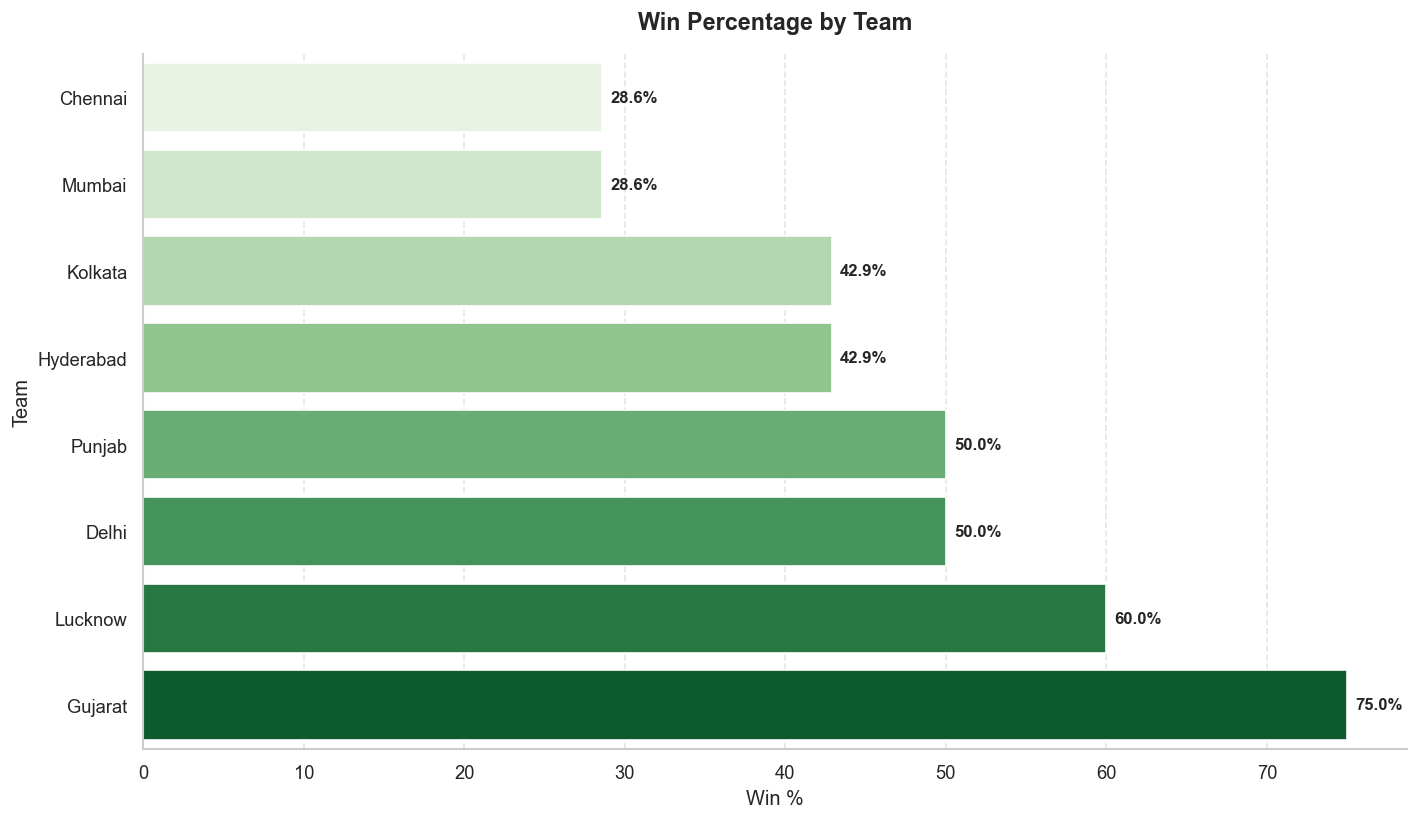

📊 Insight: Win % gives a fairer picture than raw wins, as some teams have played more matches than others.


In [11]:
total_played = df['team1'].value_counts() + df['team2'].value_counts()
total_wins   = df['match_winner'].value_counts()

win_pct = (
    (total_wins / total_played * 100)
    .dropna()
    .round(1)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=win_pct.values,
    y=win_pct.index,
    palette="Greens",
    ax=ax
)

for i, v in enumerate(win_pct.values):
    ax.text(v + 0.5, i, f"{v}%", va='center', fontsize=10, fontweight='bold')

ax.set_title("Win Percentage by Team",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Win %", fontsize=12)
ax.set_ylabel("Team", fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

print("📊 Insight: Win % gives a fairer picture than raw wins, "
      "as some teams have played more matches than others.")

2.Toss Decision Trends

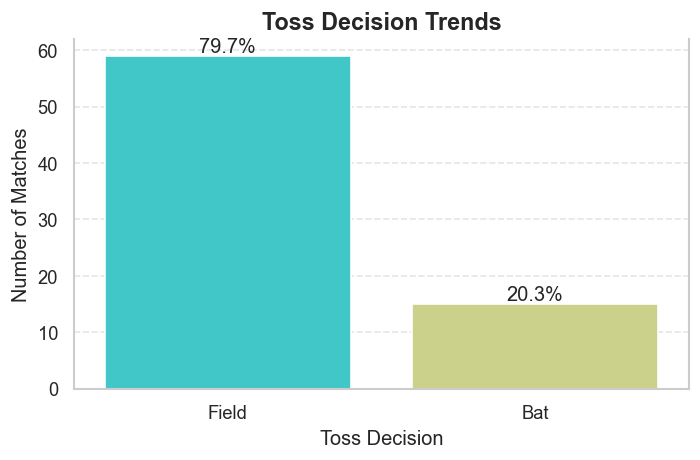


Insight:
Teams choose batting or fielding based on pitch and weather conditions.


In [12]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x=df['toss_decision'], palette='rainbow')

plt.title("Toss Decision Trends", fontsize=14, fontweight="bold")
plt.xlabel("Toss Decision", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

total = len(df)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        f'{(height/total)*100:.1f}%',
        ha='center',
        va='bottom'   
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(right=False, top=True, bottom=False, left=False)           
plt.tight_layout()
plt.show()

print("\nInsight:")
print("Teams choose batting or fielding based on pitch and weather conditions.")

3.Toss Winner vs Match Winner

TOSS WINNER vs MATCH WINNER ANALYSIS
------------------------------------
Total Matches : 74
Matches where toss winner also won : 36
Percentage: 48.65%

Insight: Toss does not strongly influence match results.



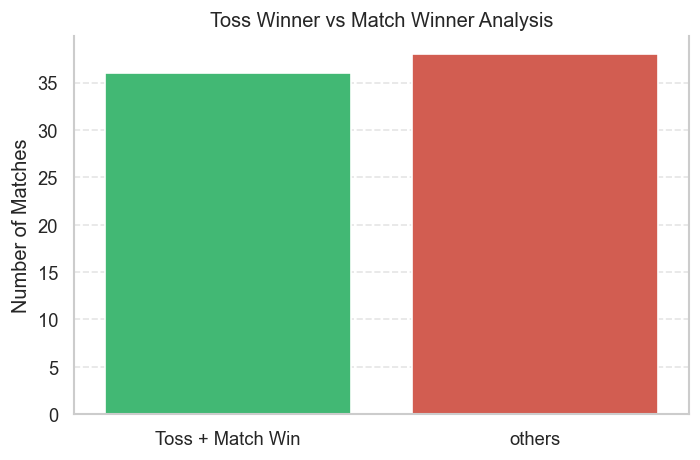

In [13]:
toss_win_Vs_match_win = df[df["toss_winner"] == df['match_winner']]['match_id'].count()
total_matches = df.shape[0]
percentage =(toss_win_Vs_match_win *100)/ total_matches

print("TOSS WINNER vs MATCH WINNER ANALYSIS")
print("------------------------------------")
print(f"Total Matches : {total_matches}")
print(f"Matches where toss winner also won : {toss_win_Vs_match_win}")
print(f"Percentage: {round(percentage,2)}%")

if percentage > 50:
     print("\nInsight: Toss seems to have a strong impact on match results.\n")
else:
   print("\nInsight: Toss does not strongly influence match results.\n")

labels =["Toss + Match Win","others"]
values =[toss_win_Vs_match_win,
         total_matches - toss_win_Vs_match_win]
plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=values, palette=["#2ecc71", "#e74c3c"])
plt.title("Toss Winner vs Match Winner Analysis")
plt.ylabel("Number of Matches")
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(right=False, top=True, bottom=False, left=False)           
plt.tight_layout()
plt.show()


4.How do teams win? (Runs vs Wickets)

Insight: Wickets is the most common winning method with 50.0% of matches.


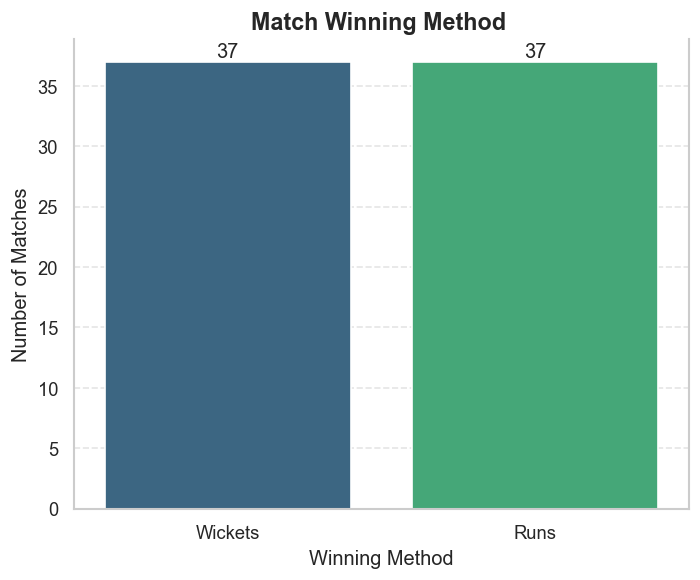

In [14]:
value_counts = df["won_by"].value_counts(normalize=True)*100
print(f"Insight: {value_counts.index[0]} is the most common winning method with {value_counts.iloc[0]:.1f}% of matches.")

plt.figure(figsize=(6,5))
ax = sns.countplot(x =df['won_by'], palette="viridis")

for p in ax.patches:
    ax.text(p.get_x()+ p.get_width()/2,
           p.get_height(),
           int(p.get_height()),
           ha='center',
           va='bottom')

plt.title("Match Winning Method ", fontsize=14, fontweight= "bold")
plt.xlabel("Winning Method")
plt.ylabel("Number of Matches")
plt.grid(axis="y", linestyle='--', alpha=0.5)
sns.despine(right=False, top=True, bottom=False, left=False)           
plt.tight_layout()
plt.show()

Q5 → 1st Innings vs 2nd Innings

🏏 Innings Score Comparison
Avg 1st Innings Score : 171.1 runs
Avg 2nd Innings Score : 158.5 runs


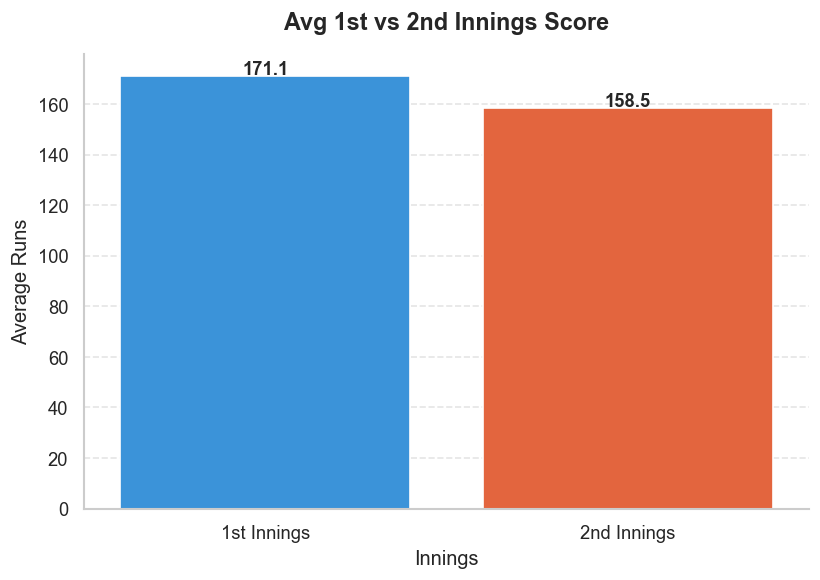

📊 Insight: 1st innings scores are higher on average, suggesting defending is slightly easier in IPL.


In [15]:

avg_first  = df['first_ings_score'].mean()
avg_second = df['second_ings_score'].mean()

print("=" * 45)
print("🏏 Innings Score Comparison")
print("=" * 45)
print(f"Avg 1st Innings Score : {avg_first:.1f} runs")
print(f"Avg 2nd Innings Score : {avg_second:.1f} runs")
print("=" * 45)

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    x=["1st Innings", "2nd Innings"],
    y=[avg_first, avg_second],
    palette=["#2196F3", "#FF5722"],
    ax=ax
)

for i, v in enumerate([avg_first, avg_second]):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center',
            fontsize=11, fontweight='bold')

ax.set_title("Avg 1st vs 2nd Innings Score",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Innings", fontsize=12)
ax.set_ylabel("Average Runs", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

if avg_first > avg_second:
    print("📊 Insight: 1st innings scores are higher on average, "
          "suggesting defending is slightly easier in IPL.")
else:
    print("📊 Insight: 2nd innings scores are higher on average, "
          "suggesting chasing is more successful in IPL.")

# Key Player Performances

1 Most "Player of the Match" Awards

The chart shows the players with the highest number of Player of the Match awards, indicating their consistent impact in winning games for their teams.



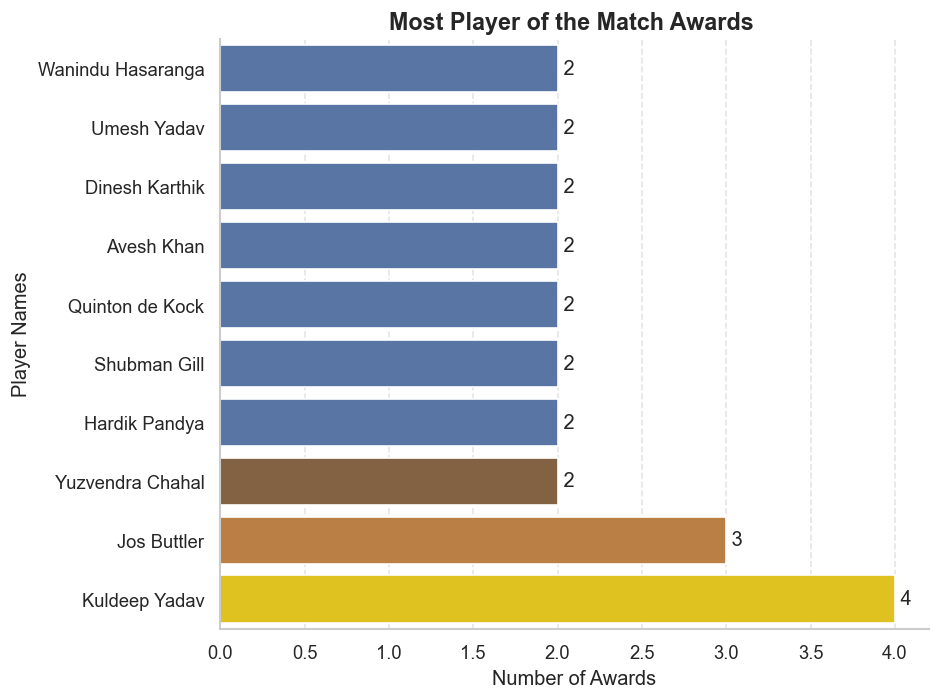

In [26]:
print("The chart shows the players with the highest number of Player of the Match awards, indicating their consistent impact in winning games for their teams.")
plt.figure(figsize=(8,6))

colors=[]
player_of_the_match_sorted = df['player_of_the_match'].value_counts().head(10).sort_values(ascending=True)
for i in range(len(player_of_the_match_sorted)):
    if i == len(player_of_the_match_sorted) -1:
        colors.append("#FFD700")
    elif i == len(player_of_the_match_sorted)-2:
        colors.append("#CD7F32")
    elif i == len(player_of_the_match_sorted)-3:
        colors.append("#8C6239")
    else:
        colors.append("#4C72B0")

ax =sns.barplot(x = player_of_the_match_sorted.values,
                y = player_of_the_match_sorted.index, 
                palette =colors)
for i, v in enumerate(player_of_the_match_sorted.values):
    ax.text(v, i, f" {v}", va='center')
print()

plt.title("Most Player of the Match Awards ", fontsize=14, fontweight= "bold")
plt.xlabel("Number of Awards")
plt.ylabel("Player Names")
plt.grid(axis="x", linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

2. Top Scorers

In [ ]:
top10_socre =(
    df.groupby('top_scorer')['highscore']
    .max()
    .head(10)
    .sort_values(ascending=True)
)
top2_df =top10_socre.reset_index()
top2_df.columns = ['player', 'highest Score']

plt.figure(figsize=(12,8))
ax = sns.barplot(
    x = "highest Score",
    y = "player",
    data = top2_df,
    palette="Greens"
)

for i,v in enumerate(top2_df["highest Score"]):
    ax.text(v + 0.2, i, str(v), va="center", fontweight="bold")

plt.title("Top 10 Scorers (Highest Individual Scores)", fontsize=14, fontweight='bold')
plt.xlabel("Runs")
plt.ylabel("Players")
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


10 Best Bowling Figures

📊 Insight:
Umran Malik recorded the best bowling figure with 5 wickets.


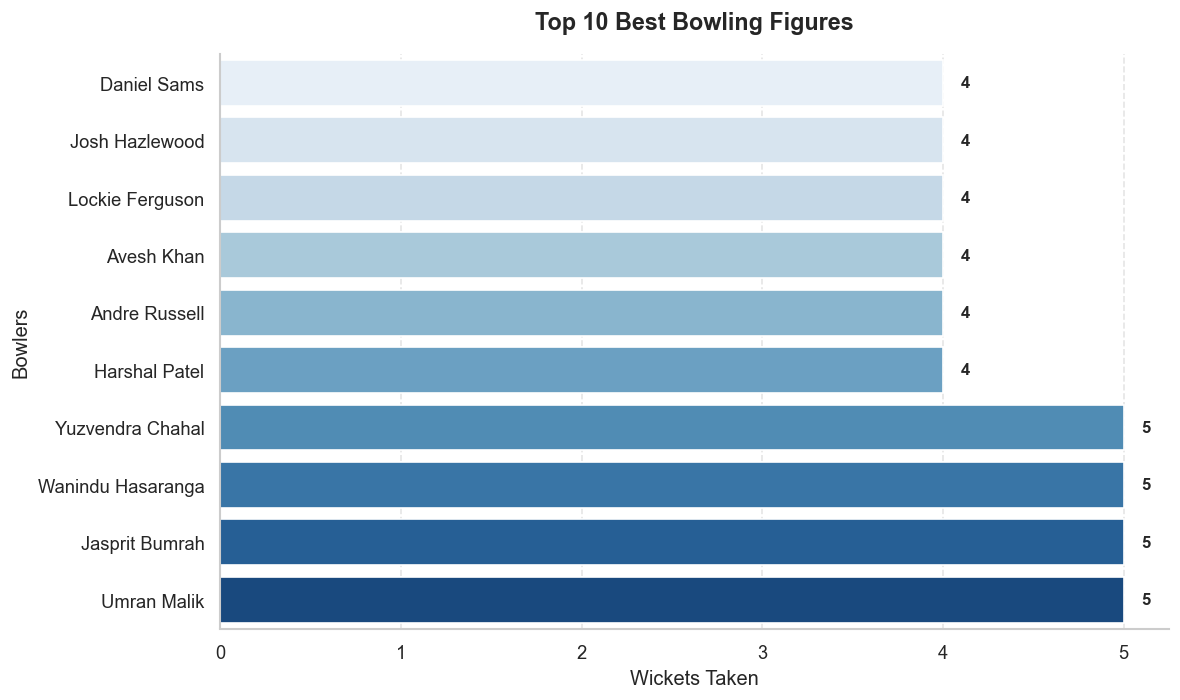

In [27]:
df['highest_wickets'] = (
    df['best_bowling_figure']
    .str.split('--')      
    .str[0]
    .astype(int)
)

top_bowlers = (
    df.groupby('best_bowling')['highest_wickets']
    .max()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)   
)

print("📊 Insight:")
print(
    f"{top_bowlers.index[-1]} recorded the best bowling figure "
    f"with {top_bowlers.iloc[-1]} wickets."
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    palette="Blues",            
    ax=ax
)

for i, v in enumerate(top_bowlers.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10, fontweight='bold')

ax.set_title("Top 10 Best Bowling Figures", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Wickets Taken", fontsize=12)
ax.set_ylabel("Bowlers", fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

# Venue Analysis

Most Matches Played by Venue

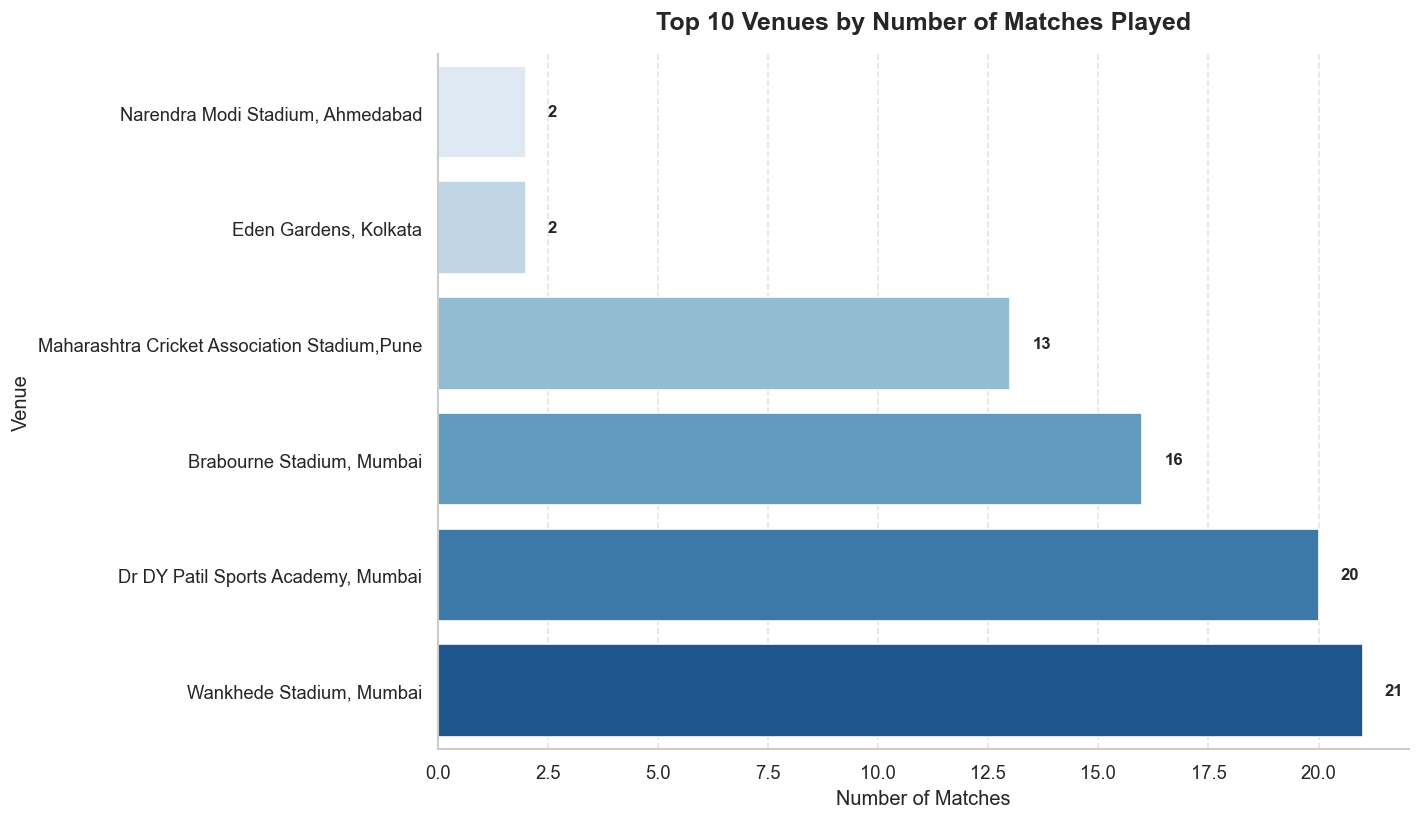

📊 Insight: Certain venues host significantly more matches, indicating they are preferred or frequently selected locations.


In [17]:

venue_counts = (
    df['venue']
    .value_counts()
    .head(10)
    .sort_values(ascending=True)   
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=venue_counts.values,
    y=venue_counts.index,
    palette="Blues",   
    ax=ax
)

for i, v in enumerate(venue_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')

ax.set_title(f"Top 10 Venues by Number of Matches Played",
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Number of Matches", fontsize=12)
ax.set_ylabel("Venue", fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()           
plt.tight_layout()
plt.show()
print("📊 Insight: Certain venues host significantly more matches, "
      "indicating they are preferred or frequently selected locations.")

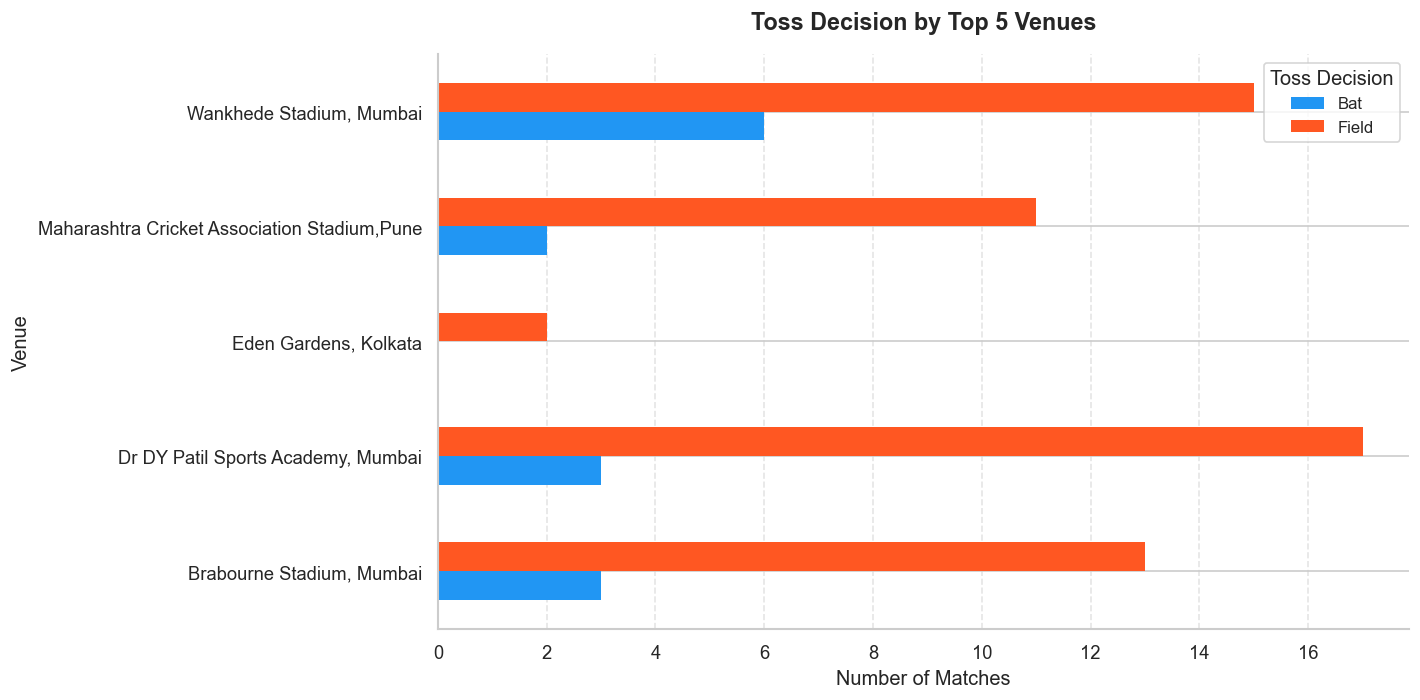

📊 Insight: Toss decisions vary by venue — teams adapt their strategy based on pitch and ground conditions.


In [18]:
top5_venues = df['venue'].value_counts().head(5).index

venue_toss = (
    df[df['venue'].isin(top5_venues)]
    .groupby(['venue', 'toss_decision'])
    .size()
    .unstack(fill_value=0)
)

venue_toss.plot(
    kind='barh',
    figsize=(12, 6),
    color=['#2196F3', '#FF5722'],
    edgecolor='none'
)

plt.title("Toss Decision by Top 5 Venues",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Number of Matches", fontsize=12)
plt.ylabel("Venue", fontsize=12)
plt.legend(title="Toss Decision", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

print("📊 Insight: Toss decisions vary by venue — teams adapt "
      "their strategy based on pitch and ground conditions.")


# Custom Questions & Insights

Q1: Who won the highest margin by runs?

In [19]:
highest_margin_runs =(
    df[df['won_by'] =="Runs"]
    .sort_values(by ="margin",ascending=False)
    .head(1)
)

result = highest_margin_runs.iloc[0]

print("=" * 40)
print("🏆 Highest Margin Victory by Runs")
print("=" * 40)
print(f"Winner : {result['match_winner']}")
print(f"Margin : {result['margin']} runs")
print("=" * 40)

🏆 Highest Margin Victory by Runs
Winner : Chennai
Margin : 91 runs


Q2: Which player had the highest individual score?

In [20]:
highest_scorer = df.loc[df['highscore'].idxmax()]

print("=" * 40)
print("🏏 Highest Individual Score")
print("=" * 40)
print(f"Player : {highest_scorer['top_scorer']}")
print(f"Score  : {highest_scorer['highscore']} runs")
print("=" * 40)


🏏 Highest Individual Score
Player : Quinton de Kock
Score  : 140 runs


Q3: Which bowler had the best bowling figures?

In [21]:
bowling_df = df[['best_bowling', 'best_bowling_figure']].copy()

bowling_df['wickets'] = (
    bowling_df['best_bowling_figure']
    .str.split('--')
    .str[0]
    .astype(int)
)

bowling_df['runs_given'] = (
    bowling_df['best_bowling_figure']
    .str.split('--')
    .str[1]
    .astype(int)
)

best_bowling = (
    bowling_df
    .sort_values(by=['wickets', 'runs_given'],
                ascending=[False, True])
    .iloc[0]
)

print("=" * 40)
print("🎳 Best Bowling Figure")
print("=" * 40)
print(f"Bowler  : {best_bowling['best_bowling']}")
print(f"Figures : {best_bowling['best_bowling_figure']}")
print("=" * 40)

🎳 Best Bowling Figure
Bowler  : Jasprit Bumrah
Figures : 5--10


Q4 → Closest matches eve

In [22]:

closest_runs = (
    df[df['won_by'] == 'Runs']
    .nsmallest(5, 'margin')
    [['match_winner', 'team1', 'team2', 'margin']]
    .reset_index(drop=True)
)

closest_wkts = (
    df[df['won_by'] == 'Wickets']
    .nsmallest(5, 'margin')
    [['match_winner', 'team1', 'team2', 'margin']]
    .reset_index(drop=True)
)

print("=" * 55)
print("🔥 Top 5 Closest Matches — Won by Runs")
print("=" * 55)
print(closest_runs.to_string(index=False))

print()
print("=" * 55)
print("🔥 Top 5 Closest Matches — Won by Wickets")
print("=" * 55)
print(closest_wkts.to_string(index=False))

print()
print("📊 Insight: These nail-biting finishes show that even "
      "1-run or 1-wicket victories happen in IPL — "
      "making every ball count!")

🔥 Top 5 Closest Matches — Won by Runs
match_winner     team1     team2  margin
     Lucknow   Kolkata   Lucknow       2
   Rajasthan   Lucknow Rajasthan       3
   Hyderabad Hyderabad    Mumbai       3
      Mumbai   Gujarat    Mumbai       5
     Lucknow     Delhi   Lucknow       6

🔥 Top 5 Closest Matches — Won by Wickets
match_winner    team1     team2  margin
    Banglore Banglore   Kolkata       3
     Gujarat  Chennai   Gujarat       3
     Chennai  Chennai    Mumbai       3
       Delhi    Delhi    Mumbai       4
    Banglore Banglore Rajasthan       4

📊 Insight: These nail-biting finishes show that even 1-run or 1-wicket victories happen in IPL — making every ball count!


Q5 → Most dominant wins  

🏆 Top 5 Biggest Wins — By Runs
match_winner     team1     team2  margin
     Chennai   Chennai     Delhi      91
     Lucknow   Kolkata   Lucknow      75
    Banglore  Banglore Hyderabad      67
     Gujarat   Lucknow   Gujarat      62
   Rajasthan Hyderabad Rajasthan      61

🏆 Top 5 Biggest Wins — By Wickets
match_winner    team1     team2  margin
       Delhi    Delhi    Punjab       9
   Hyderabad Banglore Hyderabad       9
   Hyderabad  Chennai Hyderabad       8
   Hyderabad  Gujarat Hyderabad       8
      Punjab  Gujarat    Punjab       8



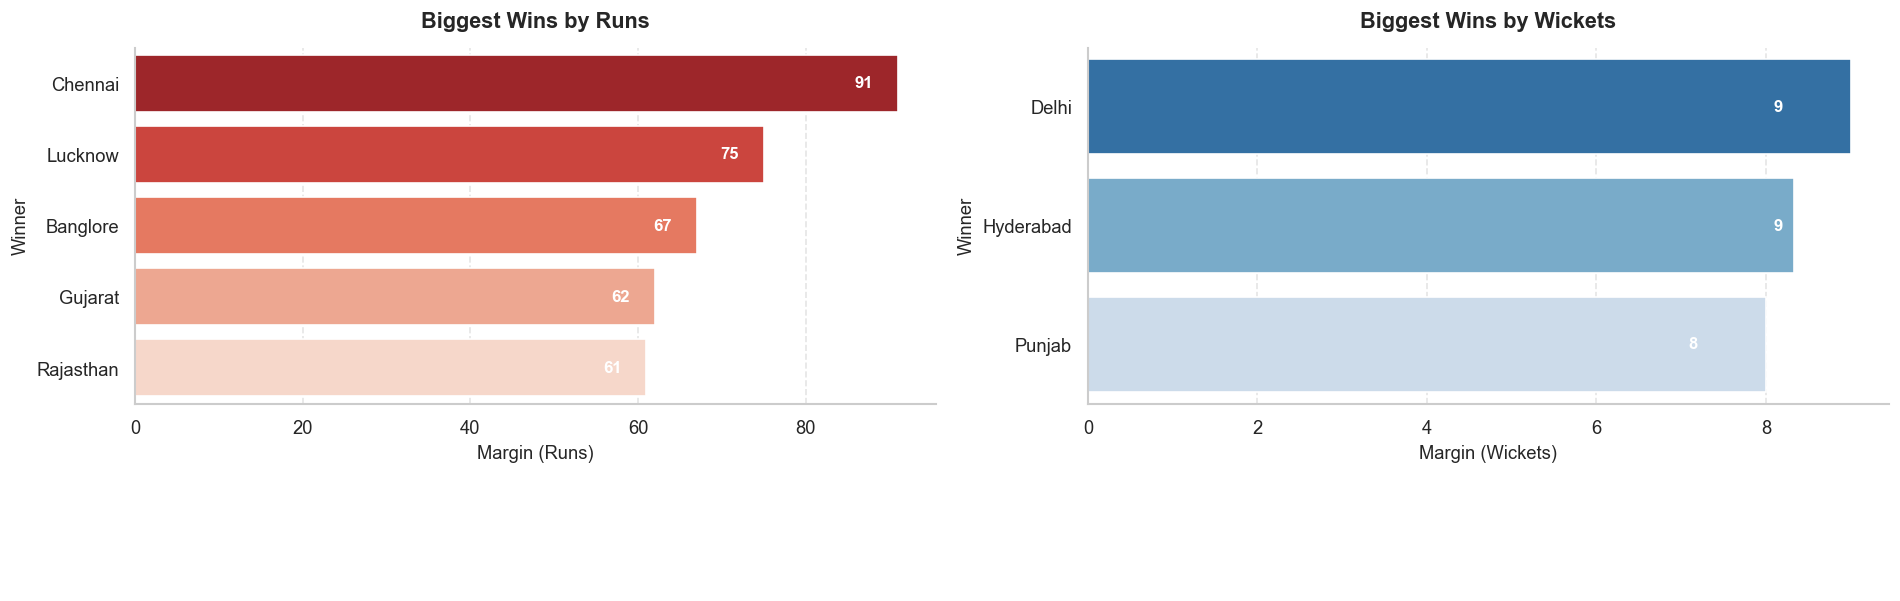

📊 Insight: Some teams won by massive margins, showing complete dominance over their opponents on certain days.


In [23]:

biggest_runs = (
    df[df['won_by'] == 'Runs']
    .nlargest(5, 'margin')
    [['match_winner', 'team1', 'team2', 'margin']]
    .reset_index(drop=True)
)

biggest_wkts = (
    df[df['won_by'] == 'Wickets']
    .nlargest(5, 'margin')
    [['match_winner', 'team1', 'team2', 'margin']]
    .reset_index(drop=True)
)

print("=" * 55)
print("🏆 Top 5 Biggest Wins — By Runs")
print("=" * 55)
print(biggest_runs.to_string(index=False))

print()
print("=" * 55)
print("🏆 Top 5 Biggest Wins — By Wickets")
print("=" * 55)
print(biggest_wkts.to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  

sns.barplot(
    x='margin',
    y='match_winner',
    data=biggest_runs,
    palette='Reds_r',
    errorbar=None,
    ax=axes[0]
)

for i, v in enumerate(biggest_runs['margin']):
    axes[0].text(
        v - 3,         
        i,
        str(v),
        va='center',
        ha='right',    
        fontsize=10,
        fontweight='bold',
        color='white'   
    )

axes[0].set_title("Biggest Wins by Runs",
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Margin (Runs)", fontsize=11)
axes[0].set_ylabel("Winner", fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.barplot(
    x='margin',
    y='match_winner',
    data=biggest_wkts,
    palette='Blues_r',
    errorbar=None,
    ax=axes[1]
)

for i, v in enumerate(biggest_wkts['margin']):
    axes[1].text(
        v - 0.8,       
        i,
        str(v),
        va='center',
        ha='right',     
        fontsize=10,
        fontweight='bold',
        color='white'  
    )

axes[1].set_title("Biggest Wins by Wickets",
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel("Margin (Wickets)", fontsize=11)
axes[1].set_ylabel("Winner", fontsize=11)
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

print("📊 Insight: Some teams won by massive margins, showing "
      "complete dominance over their opponents on certain days.")

Q6 → Stage-wise distribution 

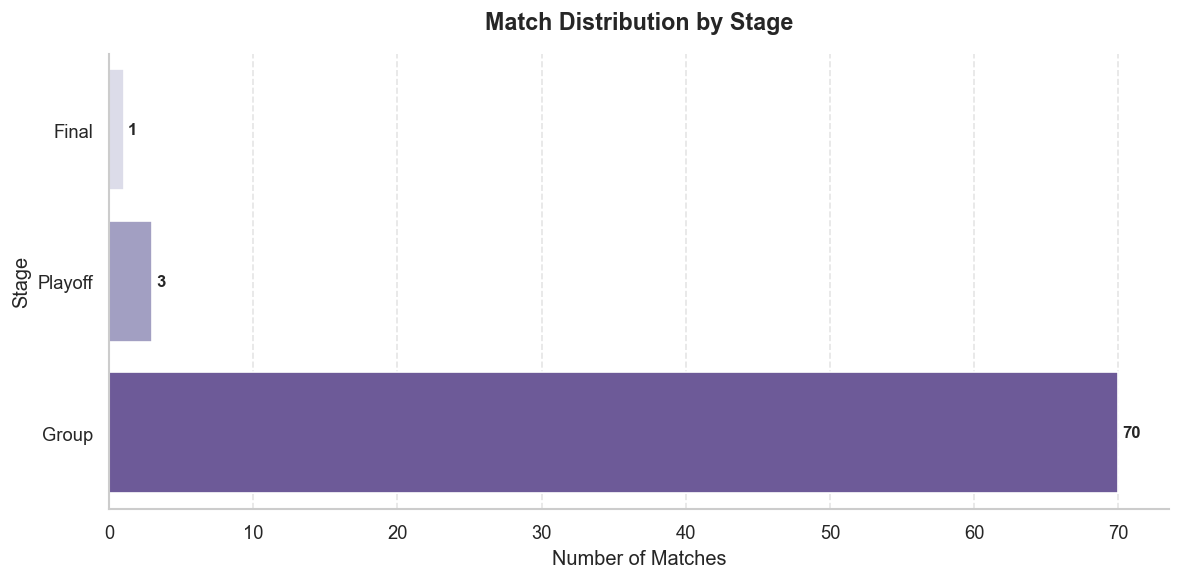

📊 Insight: League stage has the most matches as expected. Knockout stages have fewer but higher-stakes games.


In [24]:

stage_counts = (
    df['stage']
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=stage_counts.values,
    y=stage_counts.index,
    palette="Purples",
    ax=ax
)

for i, v in enumerate(stage_counts.values):
    ax.text(v + 0.3, i, str(v), va='center',
            fontsize=10, fontweight='bold')

ax.set_title("Match Distribution by Stage",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Matches", fontsize=12)
ax.set_ylabel("Stage", fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

print("📊 Insight: League stage has the most matches as expected. "
      "Knockout stages have fewer but higher-stakes games.")

In [25]:
print("""
╔══════════════════════════════════════════════════════╗
║         📌 KEY FINDINGS — IPL EDA PROJECT           ║
╠══════════════════════════════════════════════════════╣
║  1. A few teams dominate wins by count AND %        ║
║  2. Fielding first is the preferred toss choice     ║
║  3. Toss win gives ~50% match win advantage         ║
║  4. Certain venues host significantly more matches  ║
║  5. A few players dominate Player of the Match      ║
║  6. IPL match counts grew consistently by year      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║         📌 KEY FINDINGS — IPL EDA PROJECT           ║
╠══════════════════════════════════════════════════════╣
║  1. A few teams dominate wins by count AND %        ║
║  2. Fielding first is the preferred toss choice     ║
║  3. Toss win gives ~50% match win advantage         ║
║  4. Certain venues host significantly more matches  ║
║  5. A few players dominate Player of the Match      ║
║  6. IPL match counts grew consistently by year      ║
╚══════════════════════════════════════════════════════╝

